In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X.shape

(2000, 2)

In [4]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [5]:
y[1]

tensor(0.)

In [6]:
class MoonModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = torch.nn.Sequential(
            torch.nn.Linear(2,50),
            torch.nn.Tanh(),
            torch.nn.Linear(50,1)
        )
    def forward(self,x):
        x = self.hidden(x)
        return x

In [7]:
moonmodel = MoonModel()
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(moonmodel.parameters(),lr=1e-3)

In [8]:
num_epochs = 20
for i in range(num_epochs):
    for x,label in zip(X,y):
        print(f"Epoch {i+1}\n-------------------------------")
        pred = moonmodel(x.unsqueeze(0))
        loss = loss_fn(pred,label.unsqueeze(0).unsqueeze(1))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss = loss.item()
        print(f"loss: {loss:>7f}")


Epoch 1
-------------------------------
loss: 0.796096
Epoch 1
-------------------------------
loss: 0.691166
Epoch 1
-------------------------------
loss: 0.704746
Epoch 1
-------------------------------
loss: 0.747225
Epoch 1
-------------------------------
loss: 0.695268
Epoch 1
-------------------------------
loss: 0.683055
Epoch 1
-------------------------------
loss: 0.728244
Epoch 1
-------------------------------
loss: 0.698984
Epoch 1
-------------------------------
loss: 0.673939
Epoch 1
-------------------------------
loss: 0.672270
Epoch 1
-------------------------------
loss: 0.688401
Epoch 1
-------------------------------
loss: 0.664292
Epoch 1
-------------------------------
loss: 0.676958
Epoch 1
-------------------------------
loss: 0.700649
Epoch 1
-------------------------------
loss: 0.682094
Epoch 1
-------------------------------
loss: 0.698815
Epoch 1
-------------------------------
loss: 0.697459
Epoch 1
-------------------------------
loss: 0.728817
Epoch 1
--

In [9]:
theta = torch.concat([param.detach().flatten() for param in moonmodel.parameters()])

In [10]:
theta

tensor([-2.8468,  0.1118, -2.9804,  0.7576,  3.0173,  0.0527, -0.7856,  0.2117,
        -0.2763,  0.5654,  0.3983, -0.4782,  0.3695, -0.3377, -0.4507,  0.8220,
        -0.5641, -0.0275, -0.3132,  0.4028, -0.3781,  0.6202,  0.3304, -0.4270,
        -2.0237, -1.3576, -0.3266, -0.4293, -0.4460,  0.3582,  0.4447, -0.2235,
        -0.8858,  0.4063, -0.4844,  0.2938, -0.2330,  0.8719, -0.4033, -0.1801,
         0.5440, -0.3141, -0.3425,  0.4589, -0.3772,  0.4598, -0.5875,  0.3909,
        -0.7676,  0.4830,  0.3492, -0.6119, -2.7752,  0.5806, -0.3175,  0.2986,
        -0.3929,  0.3857, -0.3308,  0.3254, -0.5485,  0.4213,  0.3674, -0.5354,
        -3.3769, -0.7612, -3.3360, -0.0824, -0.4758,  0.2257,  0.7462, -0.1374,
         0.5270, -0.4822,  0.2974, -0.1919, -0.2837,  0.2684,  0.4963, -0.2114,
        -0.4017,  0.1752, -0.2798,  0.3001,  0.3708, -0.4775,  0.4715, -0.8688,
         3.3029,  0.8493,  0.3399,  0.0089,  0.3823, -0.4711, -0.3797,  0.6162,
         0.3719, -0.5916,  0.8567,  1.25

In [11]:
dim = theta.numel()

v1 = torch.randn(dim)
v2 = torch.randn(dim)

v1 = v1/v1.norm()
v2 = v2/v2.norm()

In [12]:
def set_model_params(model,params):
    pointer = 0
    for param in model.parameters():
        numel = param.numel()
        new_p = params[pointer:pointer+numel].view_as(param)
        param.data.copy_(new_p)
        pointer += numel


In [13]:
alphas = torch.linspace(-200, 200, steps=200)  # grid along v1
betas  = torch.linspace(-200, 200, steps=200)  # grid along v2
loss_grid = torch.zeros((len(alphas), len(betas)))
original_params = theta.clone()

for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        theta_new = theta + a * v1 + b * v2
        set_model_params(moonmodel, theta_new)

        # Forward pass for all training points
        preds = moonmodel(X)
        loss_val = loss_fn(preds, y.unsqueeze(1))  # ensure y shape is (N,1)
        loss_grid[i, j] = loss_val.item()

set_model_params(moonmodel, original_params)

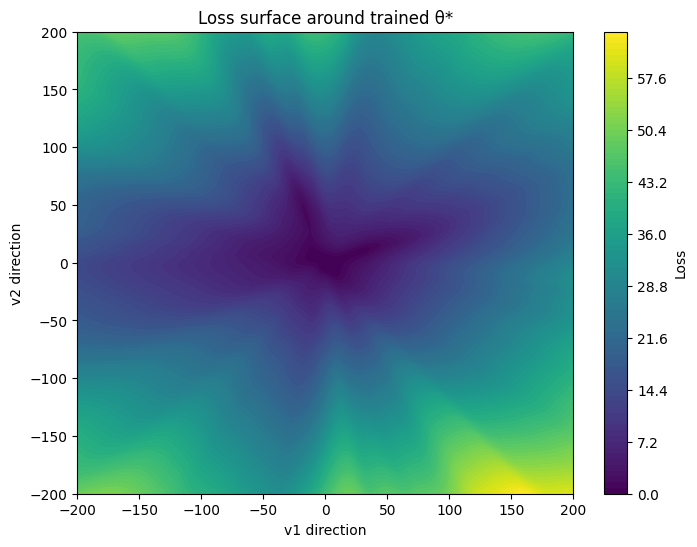

In [15]:
plt.figure(figsize=(8,6))
plt.contourf(alphas.numpy(), betas.numpy(), loss_grid.numpy(), levels=100, cmap='viridis')
plt.xlabel('v1 direction')
plt.ylabel('v2 direction')
plt.title('Loss surface around trained θ*')
plt.colorbar(label='Loss')
plt.show()